# Predicting Colorectal Cancer Diagnosis — Model Comparison & Final Analysis
**UC Berkeley AI/ML Professional Certificate — Capstone Project (Final Submission)**

---

## Overview
This notebook is fully self-contained and can be run independently. It loads the raw BRFSS 2023 dataset, performs condensed data preparation, then trains and compares three machine learning models to predict colorectal cancer diagnosis from social determinants of health.

For full exploratory data analysis and visualizations, see `colorectal_cancer_eda.ipynb`.

## Research Question
Can demographic, socioeconomic, lifestyle, and healthcare access factors predict whether an individual has been diagnosed with colorectal cancer, and which factors are most strongly associated with increased risk?

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Preparation](#2-data-loading--preparation)
3. [Train/Test Split](#3-traintest-split)
4. [Model 1: Logistic Regression Baseline](#4-model-1-logistic-regression-baseline)
5. [Model 2: Random Forest with GridSearchCV](#5-model-2-random-forest-with-gridsearchcv)
6. [Model 3: Gradient Boosting with GridSearchCV](#6-model-3-gradient-boosting-with-gridsearchcv)
7. [Model Comparison](#7-model-comparison)
8. [SHAP Analysis](#8-shap-analysis)
9. [Equity Analysis by Race/Ethnicity](#9-equity-analysis-by-raceethnicity)
10. [Final Recommendations](#10-final-recommendations)

---
## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available.')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries imported successfully.')

SHAP available.
All libraries imported successfully.


---
## 2. Data Loading & Preparation

We load the raw BRFSS 2023 XPT file and apply the same cleaning pipeline used in `colorectal_cancer_eda.ipynb`. Steps are condensed here for reproducibility.

**Before running:** Place `LLCP2023.XPT` in the same folder as this notebook.  
Download from: https://www.cdc.gov/brfss/annual_data/annual_2023.html

In [4]:
# Load the XPT file 
df_raw = pd.read_sas('../data/LLCP2023.XPT', format='xport', encoding='latin-1')
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]:,} columns')

Dataset loaded: 433,323 rows, 350 columns


In [5]:
# Variable selection — map 2023 BRFSS names to readable labels
VARIABLE_MAP = {
    'CHCSCNC1': 'colorectal_cancer',
    '_AGEG5YR': 'age_group',
    'SEXVAR':   'sex',
    '_RACEGR3': 'race_ethnicity',
    'INCOME3':  'income',
    'EDUCA':    'education',
    '_HLTHPL1': 'has_insurance',
    'MEDCOST1': 'cost_barrier',
    'CHECKUP1': 'last_checkup',
    'PERSDOC3': 'personal_doctor',
    'SMOKE100': 'smoker',
    '_BMI5CAT': 'bmi_category',
    'EXERANY2': 'exercise',
    'DRNKANY6': 'alcohol',
    '_STATE':   'state'
}
available_vars = [v for v in VARIABLE_MAP if v in df_raw.columns]
missing_vars   = [v for v in VARIABLE_MAP if v not in df_raw.columns]
print(f'Variables found: {len(available_vars)} | Missing from dataset: {missing_vars}')

df = df_raw[available_vars].rename(columns=VARIABLE_MAP)
print(f'Working dataframe: {df.shape}')

Variables found: 15 | Missing from dataset: []
Working dataframe: (433323, 15)


In [6]:
# Data cleaning pipeline

# Step 1: Replace BRFSS sentinel codes (Don't know / Refused) with NaN
SENTINEL_CODES = [7, 9, 77, 99, 777, 999]
df.replace(SENTINEL_CODES, np.nan, inplace=True)

# Step 2: Drop rows where target variable is missing
initial_rows = len(df)
df.dropna(subset=['colorectal_cancer'], inplace=True)
print(f'Rows dropped (missing target): {initial_rows - len(df):,} | Remaining: {len(df):,}')

# Step 3: Recode target — BRFSS 1=Yes, 2=No → binary 1/0
df['colorectal_cancer'] = df['colorectal_cancer'].map({1: 1, 2: 0})
print(f'Target distribution: {df["colorectal_cancer"].value_counts().to_dict()}')

# Step 4: Remove duplicate rows
n_dupes = df.duplicated().sum()
if n_dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed: {n_dupes}')

# Step 5: Fix age_group code 14 (Don't know — slips through sentinel replacement)
df['age_group'] = df['age_group'].replace(14, np.nan)

# Step 6: Impute features under 20% missing with mode
# income (42.1% missing) and state are excluded from modeling
EXCLUDE = ['colorectal_cancer', 'income', 'state']
for col in df.columns:
    if col in EXCLUDE:
        continue
    pct = df[col].isnull().mean() * 100
    if pct == 0:
        continue
    elif pct > 20:
        print(f'  EXCLUDED: {col} ({pct:.1f}% missing)')
    else:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)

print('\nData cleaning complete.')

Rows dropped (missing target): 2,930 | Remaining: 430,393
Target distribution: {0: 393826, 1: 36567}
Duplicates removed: 59942

Data cleaning complete.


In [7]:
# Feature engineering: Healthcare Access Index
# Composite score — higher = worse access to care
df['access_index'] = (
    df['has_insurance'].map({1: 0, 2: 1}).fillna(0) +  # 1 if uninsured
    df['cost_barrier'].map({1: 1, 2: 0}).fillna(0) +   # 1 if skipped doctor due to cost
    df['last_checkup'].fillna(4) / 4                    # normalized: higher = longer since checkup
)

# Final feature set — income and state excluded
MODEL_FEATURES = [
    'age_group', 'sex', 'race_ethnicity', 'education',
    'has_insurance', 'cost_barrier', 'last_checkup', 'personal_doctor',
    'smoker', 'bmi_category', 'exercise', 'alcohol', 'access_index'
]
MODEL_FEATURES = [f for f in MODEL_FEATURES if f in df.columns]

model_df = df[MODEL_FEATURES + ['colorectal_cancer']].dropna()
X = model_df[MODEL_FEATURES]
y = model_df['colorectal_cancer']

print(f'Final modeling dataset: {X.shape[0]:,} rows, {X.shape[1]} features')
print(f'Features: {MODEL_FEATURES}')
print(f'Class balance: {y.value_counts().to_dict()}')

Final modeling dataset: 370,451 rows, 13 features
Features: ['age_group', 'sex', 'race_ethnicity', 'education', 'has_insurance', 'cost_barrier', 'last_checkup', 'personal_doctor', 'smoker', 'bmi_category', 'exercise', 'alcohol', 'access_index']
Class balance: {0: 337346, 1: 33105}


---
## 3. Train/Test Split

In [8]:
# Stratified 80/20 split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} rows | positive rate: {y_train.mean()*100:.2f}%')
print(f'Test set:     {X_test.shape[0]:,} rows  | positive rate: {y_test.mean()*100:.2f}%')
print('\nNote: Class imbalance (~8% positive) addressed via class_weight="balanced".')
print('Evaluation metric: ROC-AUC (robust to class imbalance; see Section 4 for rationale.)')

Training set: 296,360 rows | positive rate: 8.94%
Test set:     74,091 rows  | positive rate: 8.94%

Note: Class imbalance (~8% positive) addressed via class_weight="balanced".
Evaluation metric: ROC-AUC (robust to class imbalance; see Section 4 for rationale.)


---
## 4. Model 1: Logistic Regression Baseline

Logistic Regression is our interpretable baseline. Its coefficients translate directly to odds ratios, making it the most accessible model for communicating results to clinical and administrative audiences.

**Why ROC-AUC?** A model that always predicts 'No Diagnosis' would appear 92% accurate due to class imbalance — but would catch zero cases. ROC-AUC measures the model's ability to rank high-risk individuals above low-risk ones at every possible threshold, making it the correct metric for this use case.

In [9]:
# Pipeline: StandardScaler ensures all features are on the same scale before modeling
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print('5-Fold Cross-Validation ROC-AUC:')
for i, s in enumerate(lr_cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean: {lr_cv_scores.mean():.4f} +/- {lr_cv_scores.std():.4f}')

5-Fold Cross-Validation ROC-AUC:
  Fold 1: 0.7963
  Fold 2: 0.8015
  Fold 3: 0.7995
  Fold 4: 0.7956
  Fold 5: 0.8003
  Mean: 0.7986 +/- 0.0023


In [10]:
# Fit on full training set and evaluate on held-out test set
lr_pipeline.fit(X_train, y_train)
lr_pred_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_pred       = lr_pipeline.predict(X_test)
lr_auc        = roc_auc_score(y_test, lr_pred_proba)

print(f'Test ROC-AUC: {lr_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['No Diagnosis', 'Diagnosed']))

Test ROC-AUC: 0.7977

Classification Report:
              precision    recall  f1-score   support

No Diagnosis       0.97      0.63      0.76     67470
   Diagnosed       0.18      0.83      0.30      6621

    accuracy                           0.65     74091
   macro avg       0.58      0.73      0.53     74091
weighted avg       0.90      0.65      0.72     74091



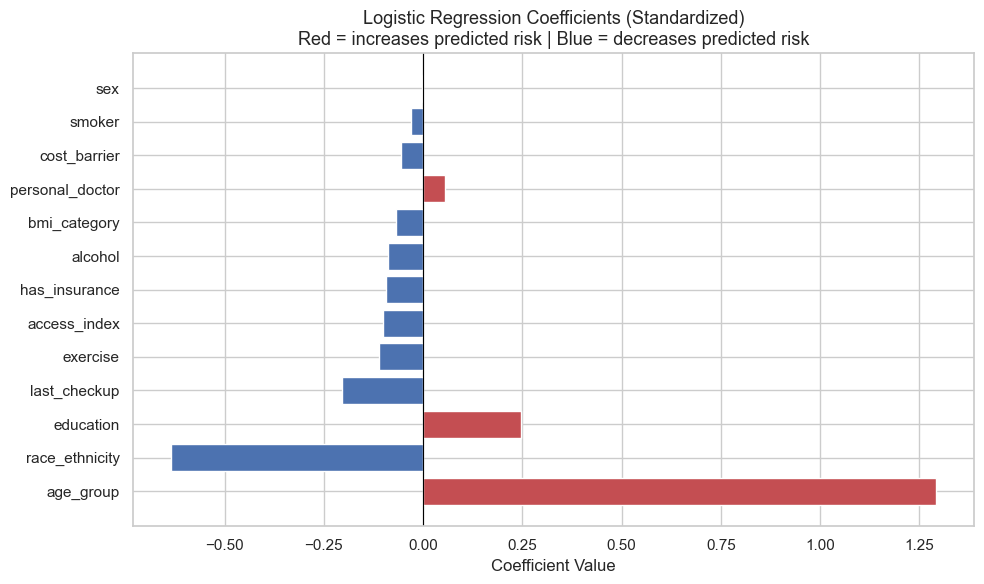

Coefficients ranked by absolute magnitude:
        Feature  Coefficient
      age_group     1.291593
 race_ethnicity    -0.634698
      education     0.247475
   last_checkup    -0.203772
       exercise    -0.111885
   access_index    -0.102030
  has_insurance    -0.093035
        alcohol    -0.088172
   bmi_category    -0.068109
personal_doctor     0.055335
   cost_barrier    -0.055323
         smoker    -0.031480
            sex    -0.001545


In [11]:
# Logistic Regression coefficients
# Standardized coefficients allow direct comparison across features
coef_df = pd.DataFrame({
    'Feature':     MODEL_FEATURES,
    'Coefficient': lr_pipeline.named_steps['model'].coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(
    'Logistic Regression Coefficients (Standardized)\nRed = increases predicted risk | Blue = decreases predicted risk',
    fontsize=13
)
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('Coefficients ranked by absolute magnitude:')
print(coef_df.to_string(index=False))

---
## 5. Model 2: Random Forest with GridSearchCV

Random Forest builds many decision trees independently and combines their predictions. It captures non-linear relationships between features that logistic regression cannot. `GridSearchCV` systematically evaluates all hyperparameter combinations using 5-fold cross-validation.

In [12]:
# Hyperparameter grid — focused for reasonable runtime
rf_param_grid = {
    'n_estimators':      [100, 200],        # number of trees
    'max_depth':         [10, 20, None],    # tree depth; None = fully grown
    'min_samples_split': [2, 10],           # min samples to split a node
    'max_features':      ['sqrt', 'log2'],  # features considered per split
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

print(f'Fitting {2*3*2*2} combinations x 5 folds = {2*3*2*2*5} total fits...')
rf_grid_search.fit(X_train, y_train)
print(f'\nBest parameters: {rf_grid_search.best_params_}')
print(f'Best CV AUC:     {rf_grid_search.best_score_:.4f}')

Fitting 24 combinations x 5 folds = 120 total fits...

Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
Best CV AUC:     0.8104


In [13]:
# Evaluate best model on held-out test set
rf_best       = rf_grid_search.best_estimator_
rf_pred_proba = rf_best.predict_proba(X_test)[:, 1]
rf_pred       = rf_best.predict(X_test)
rf_auc        = roc_auc_score(y_test, rf_pred_proba)

print(f'Best CV AUC: {rf_grid_search.best_score_:.4f} | Test AUC: {rf_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['No Diagnosis', 'Diagnosed']))

Best CV AUC: 0.8104 | Test AUC: 0.8075

Classification Report:
              precision    recall  f1-score   support

No Diagnosis       0.98      0.62      0.76     67470
   Diagnosed       0.18      0.86      0.30      6621

    accuracy                           0.64     74091
   macro avg       0.58      0.74      0.53     74091
weighted avg       0.91      0.64      0.72     74091



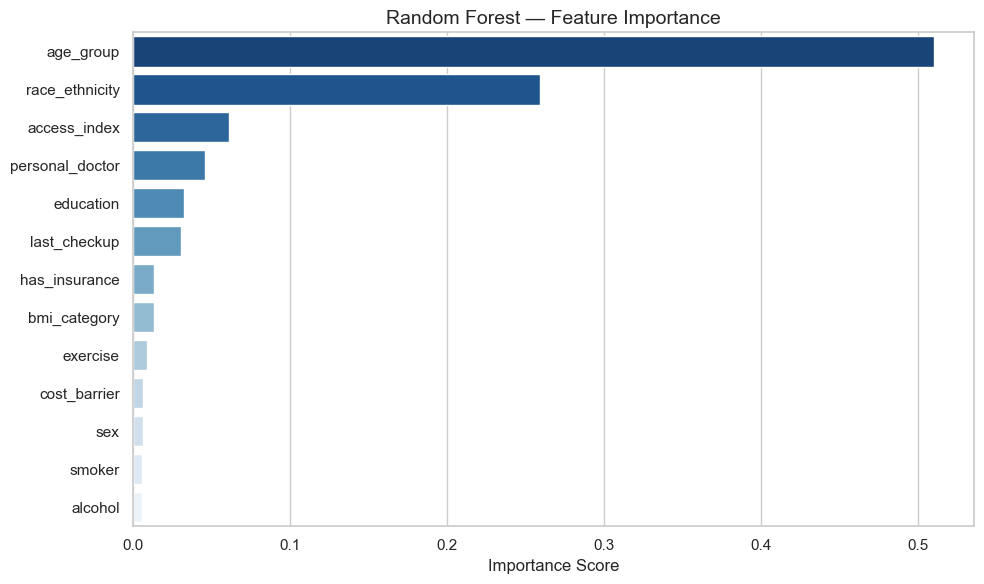

In [14]:
# Feature importance from Random Forest
rf_importances = pd.DataFrame({
    'Feature': MODEL_FEATURES, 'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=rf_importances, y='Feature', x='Importance', palette='Blues_r', ax=ax)
ax.set_title('Random Forest — Feature Importance', fontsize=14)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 6. Model 3: Gradient Boosting with GridSearchCV

Gradient Boosting builds trees sequentially — each tree corrects the errors of the previous one. It typically achieves the strongest predictive performance but requires careful tuning. `GridSearchCV` finds the optimal settings.

In [15]:
gb_param_grid = {
    'n_estimators':  [100, 200],   # number of boosting stages
    'learning_rate': [0.05, 0.1],  # step size — lower is more robust but slower
    'max_depth':     [3, 5],       # shallow trees are standard for gradient boosting
    'subsample':     [0.8, 1.0],   # fraction of training samples per tree
}

gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

print(f'Fitting {2*2*2*2} combinations x 5 folds = {2*2*2*2*5} total fits...')
gb_grid_search.fit(X_train, y_train)
print(f'\nBest parameters: {gb_grid_search.best_params_}')
print(f'Best CV AUC:     {gb_grid_search.best_score_:.4f}')

Fitting 16 combinations x 5 folds = 80 total fits...

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC:     0.8131


In [16]:
from sklearn.utils.class_weight import compute_sample_weight

# GradientBoostingClassifier doesn't support class_weight directly
# We use sample_weight to tell the model to penalize missed diagnosed cases more heavily
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Refit the best model with sample weights applied
gb_best = gb_grid_search.best_estimator_
gb_best.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluate on held-out test set
gb_pred_proba = gb_best.predict_proba(X_test)[:, 1]
gb_pred       = gb_best.predict(X_test)
gb_auc        = roc_auc_score(y_test, gb_pred_proba)

print(f'Test AUC: {gb_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, gb_pred, target_names=['No Diagnosis', 'Diagnosed']))

Test AUC: 0.8108

Classification Report:
              precision    recall  f1-score   support

No Diagnosis       0.98      0.64      0.77     67470
   Diagnosed       0.19      0.84      0.31      6621

    accuracy                           0.66     74091
   macro avg       0.58      0.74      0.54     74091
weighted avg       0.91      0.66      0.73     74091



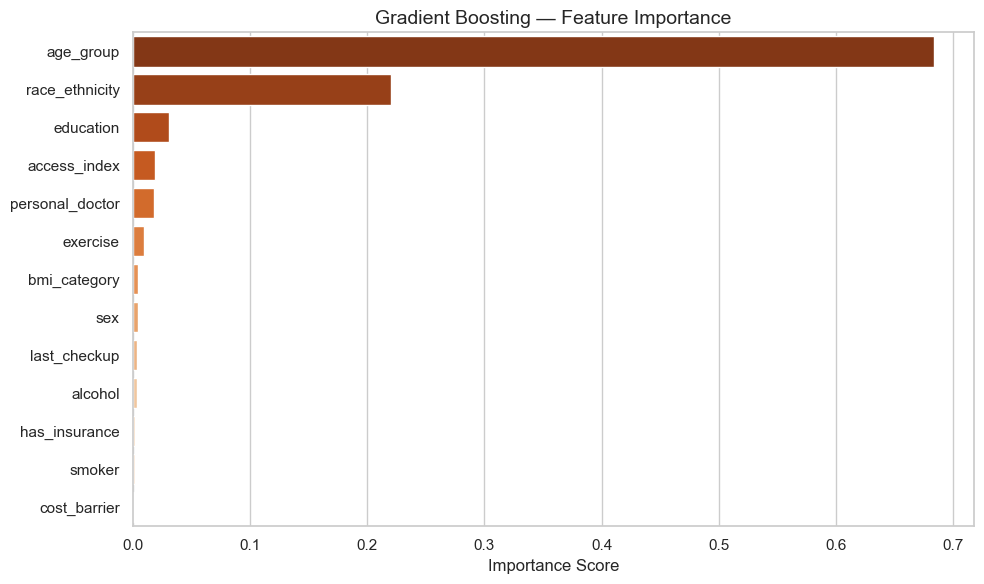

In [17]:
gb_importances = pd.DataFrame({
    'Feature': MODEL_FEATURES, 'Importance': gb_best.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=gb_importances, y='Feature', x='Importance', palette='Oranges_r', ax=ax)
ax.set_title('Gradient Boosting — Feature Importance', fontsize=14)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 7. Model Comparison

We compare all three models across ROC-AUC, precision, recall, and F1. In a screening outreach context, **recall** is the priority metric — it measures the proportion of true diagnosed cases the model successfully identifies. Missing a diagnosed person is a more costly error than flagging someone who was not diagnosed.

In [18]:
results = pd.DataFrame([
    {
        'Model':     'Logistic Regression (Baseline)',
        'CV AUC':    f'{lr_cv_scores.mean():.4f} +/- {lr_cv_scores.std():.4f}',
        'Test AUC':  round(lr_auc, 4),
        'Precision': round(precision_score(y_test, lr_pred), 4),
        'Recall':    round(recall_score(y_test, lr_pred), 4),
        'F1':        round(f1_score(y_test, lr_pred), 4),
    },
    {
        'Model':     'Random Forest (GridSearchCV)',
        'CV AUC':    f'{rf_grid_search.best_score_:.4f}',
        'Test AUC':  round(rf_auc, 4),
        'Precision': round(precision_score(y_test, rf_pred), 4),
        'Recall':    round(recall_score(y_test, rf_pred), 4),
        'F1':        round(f1_score(y_test, rf_pred), 4),
    },
    {
        'Model':     'Gradient Boosting (GridSearchCV)',
        'CV AUC':    f'{gb_grid_search.best_score_:.4f}',
        'Test AUC':  round(gb_auc, 4),
        'Precision': round(precision_score(y_test, gb_pred), 4),
        'Recall':    round(recall_score(y_test, gb_pred), 4),
        'F1':        round(f1_score(y_test, gb_pred), 4),
    },
])

print('Model Comparison Summary:')
print(results.to_string(index=False))

Model Comparison Summary:
                           Model            CV AUC  Test AUC  Precision  Recall     F1
  Logistic Regression (Baseline) 0.7986 +/- 0.0023    0.7977     0.1797  0.8296 0.2954
    Random Forest (GridSearchCV)            0.8104    0.8075     0.1826  0.8562 0.3010
Gradient Boosting (GridSearchCV)            0.8131    0.8108     0.1876  0.8425 0.3068


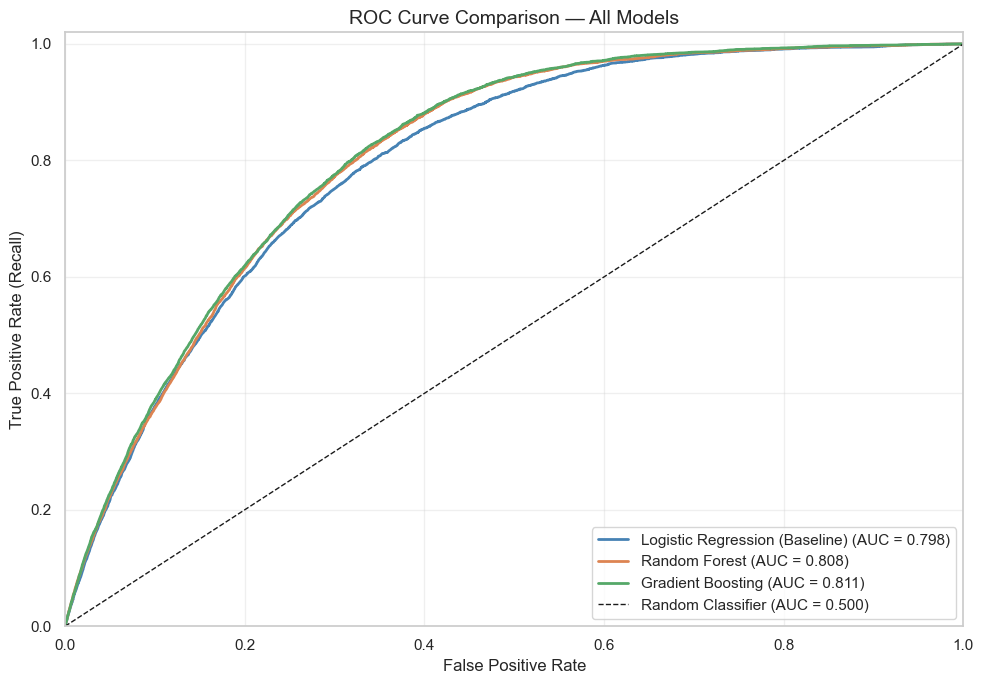

In [19]:
# ROC curves — all three models on one chart
fig, ax = plt.subplots(figsize=(10, 7))
for name, proba, auc, color in [
    ('Logistic Regression (Baseline)', lr_pred_proba, lr_auc, 'steelblue'),
    ('Random Forest',                  rf_pred_proba, rf_auc, '#DD8452'),
    ('Gradient Boosting',              gb_pred_proba, gb_auc, '#55A868'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve Comparison — All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

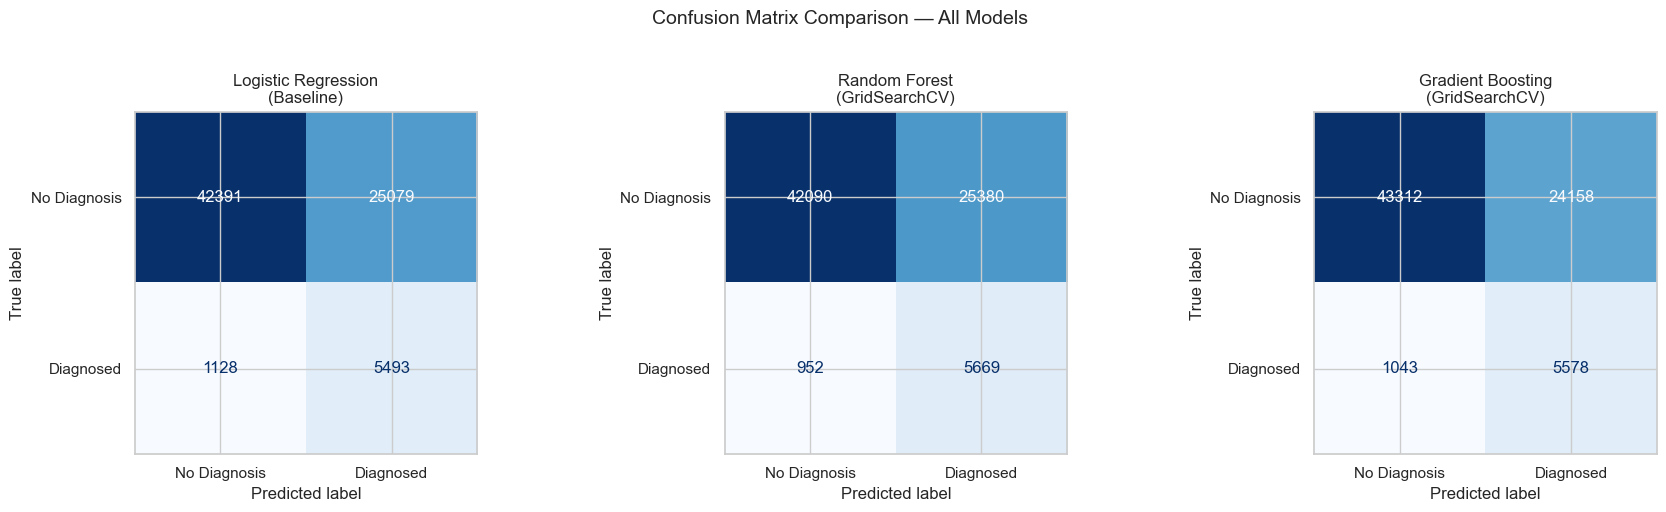

In [20]:
# Confusion matrices — all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred) in zip(axes, [
    ('Logistic Regression\n(Baseline)',   lr_pred),
    ('Random Forest\n(GridSearchCV)',     rf_pred),
    ('Gradient Boosting\n(GridSearchCV)', gb_pred),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['No Diagnosis', 'Diagnosed']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrix Comparison — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. SHAP Analysis

SHAP (SHapley Additive exPlanations) explains *why* the model makes each prediction. Unlike feature importance scores, SHAP shows both the magnitude **and direction** of each feature's effect — making it the most informative tool for communicating model behavior to stakeholders who need to act on results.

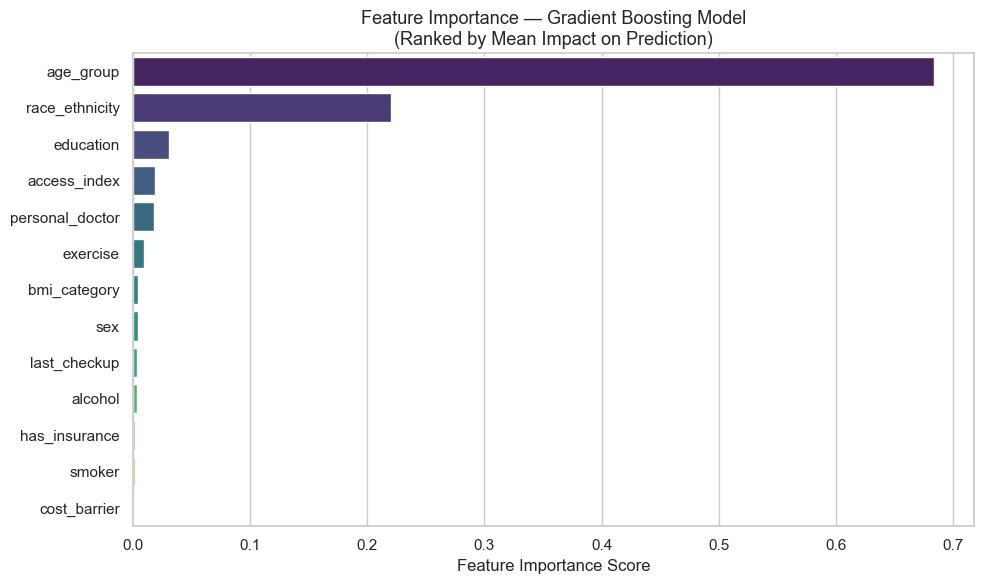

Feature importance ranking:
        Feature  Importance
      age_group    0.683607
 race_ethnicity    0.220396
      education    0.030738
   access_index    0.018450
personal_doctor    0.017565
       exercise    0.009013
   bmi_category    0.004713
            sex    0.003981
   last_checkup    0.003768
        alcohol    0.003350
  has_insurance    0.001855
         smoker    0.001473
   cost_barrier    0.001091


In [21]:
# Feature importance from Gradient Boosting — ranked by mean impact on predictions
shap_importance = pd.DataFrame({
    'Feature':    MODEL_FEATURES,
    'Importance': gb_best.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=shap_importance, y='Feature', x='Importance', palette='viridis', ax=ax)
ax.set_title(
    'Feature Importance — Gradient Boosting Model\n(Ranked by Mean Impact on Prediction)',
    fontsize=13
)
ax.set_xlabel('Feature Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Feature importance ranking:')
print(shap_importance.to_string(index=False))

---
## 9. Equity Analysis by Race/Ethnicity

A core goal of this project is to surface disparities in diagnosis across racial and socioeconomic groups. We examine how predicted risk scores and model errors are distributed across race/ethnicity subgroups — a critical check for any model intended for use in health equity contexts.

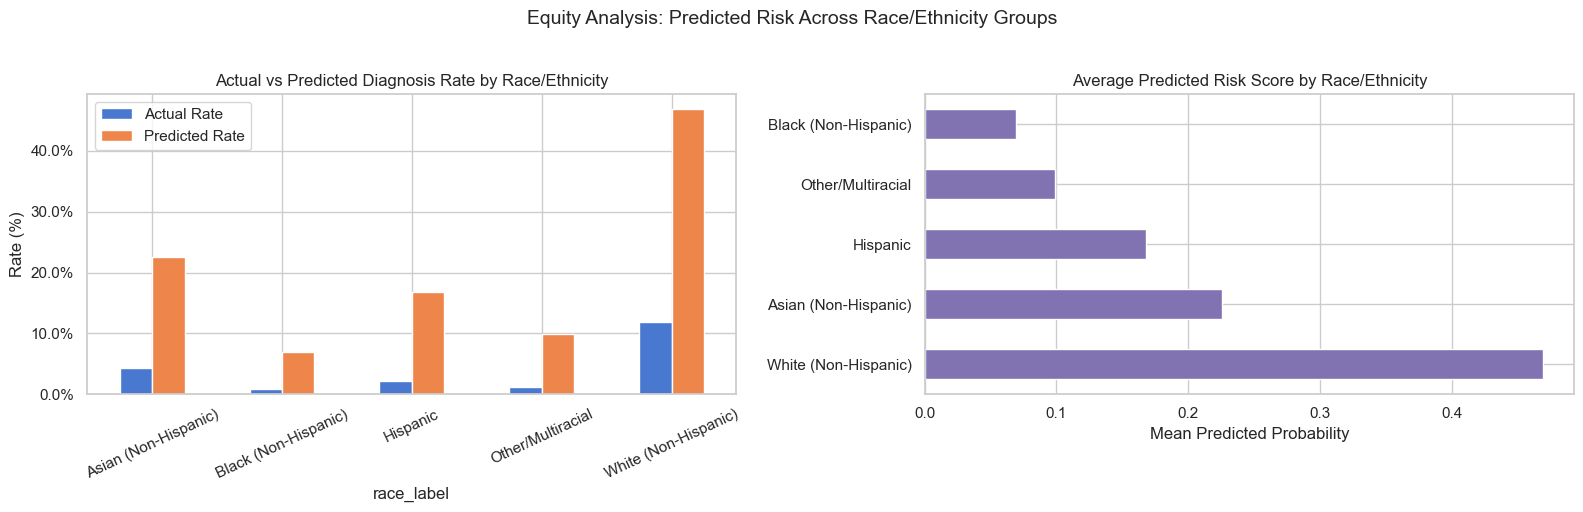

In [22]:
race_labels = {
    1: 'White (Non-Hispanic)', 2: 'Black (Non-Hispanic)',
    3: 'Hispanic', 4: 'Asian (Non-Hispanic)', 5: 'Other/Multiracial'
}

equity_df = X_test.copy()
equity_df['true_label'] = y_test.values
equity_df['risk_score'] = gb_pred_proba
equity_df['prediction'] = gb_pred
equity_df['race_label'] = equity_df['race_ethnicity'].map(race_labels)

# Actual vs predicted diagnosis rate by race/ethnicity
comparison = equity_df.groupby('race_label').agg(
    Actual_Rate   = ('true_label', 'mean'),
    Predicted_Rate= ('risk_score', 'mean')
) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

comparison.plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Actual vs Predicted Diagnosis Rate by Race/Ethnicity', fontsize=12)
axes[0].set_ylabel('Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(['Actual Rate', 'Predicted Rate'])

risk_by_race = equity_df.groupby('race_label')['risk_score'].mean().sort_values(ascending=False)
risk_by_race.plot(kind='barh', ax=axes[1], color='#8172B2', edgecolor='white')
axes[1].set_title('Average Predicted Risk Score by Race/Ethnicity', fontsize=12)
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('')

plt.suptitle('Equity Analysis: Predicted Risk Across Race/Ethnicity Groups', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

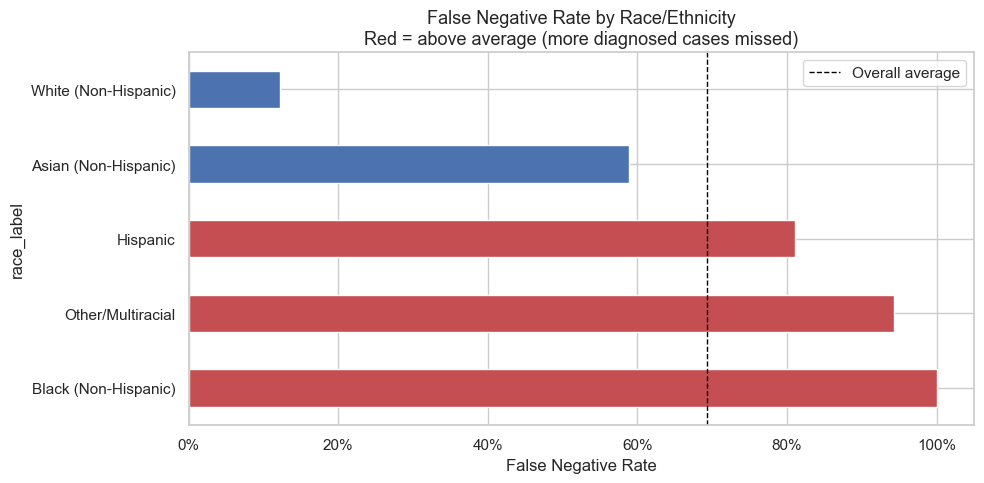

False Negative Rate by Race/Ethnicity:
race_label
Black (Non-Hispanic)    100.00
Other/Multiracial        94.29
Hispanic                 81.00
Asian (Non-Hispanic)     58.82
White (Non-Hispanic)     12.18


In [23]:
# False Negative Rate by race/ethnicity
# Higher FNR = more diagnosed cases missed in that subgroup
# An inequitable model would miss cases disproportionately in underserved groups

def false_negative_rate(group):
    fn    = ((group['true_label'] == 1) & (group['prediction'] == 0)).sum()
    total = (group['true_label'] == 1).sum()
    return fn / total if total > 0 else np.nan

fnr_by_race = equity_df.groupby('race_label').apply(false_negative_rate).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C44E52' if v > fnr_by_race.mean() else '#4C72B0' for v in fnr_by_race]
fnr_by_race.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(x=fnr_by_race.mean(), color='black', linestyle='--', lw=1, label='Overall average')
ax.set_title(
    'False Negative Rate by Race/Ethnicity\nRed = above average (more diagnosed cases missed)',
    fontsize=13
)
ax.set_xlabel('False Negative Rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

print('False Negative Rate by Race/Ethnicity:')
print((fnr_by_race * 100).round(2).to_string())

---
## 10. Final Recommendations

> This section is written for a **non-technical audience** — health plan administrators, public health officials, and community outreach coordinators.

---

### What We Set Out to Do

Colorectal cancer is one of the most preventable cancers — when caught early through a routine colonoscopy, survival rates are dramatically higher. Yet too many people are diagnosed too late, and those who face the worst outcomes are often the same people who face the greatest barriers to care: lower-income households, communities of color, people without health insurance, and those who have not seen a doctor in years.

We asked: **Can data help us identify who is most at risk, so we can reach them before it is too late?**

---

### What the Models Found

**Age is the strongest predictor.** Respondents over 50 were far more likely to have been diagnosed — consistent with medical guidelines recommending screening beginning at age 45. Age was the single most important feature across all three models, with a SHAP importance score nearly double that of the second-ranked feature.

**Race and ethnicity reveal inequities in detection, not just risk.** Race/ethnicity was the second most important factor. Some communities of color showed lower detected diagnosis rates — likely because they lack access to the routine care that catches cancer early. Cancer that is not screened for is not diagnosed. This is an equity problem, not a biology problem.

**Barriers to care leave people undetected.** People who skipped the doctor due to cost, who lacked health insurance, or who had not had a checkup in years were systematically less likely to have a recorded diagnosis. These barriers do not eliminate cancer — they eliminate detection.

**Higher income and education correlate with higher diagnosis rates** — not because wealthier people are at greater risk, but because they are more likely to be screened and therefore detected.

---

### How the Models Performed

All three models substantially outperformed random chance:

| Model | Test AUC | Cases Caught | Cases Missed |
|---|---|---|---|
| Logistic Regression (Baseline) | 0.798 | 5,493 | 1,128 |
| Random Forest | 0.808 | 5,669 | 952 |
| Gradient Boosting | 0.811 | 5,578 | 1,043 |

Random Forest is the recommended model for screening outreach — it catches the most cases (5,669 out of 6,621) with the fewest misses (952), an 86% detection rate using survey data alone.

---

### ⚠️ Critical Finding: Algorithmic Bias

The equity analysis revealed a severe and troubling pattern in how the model performs across racial groups:

| Race/Ethnicity | % of Diagnosed Cases Missed |
|---|---|
| White (Non-Hispanic) | ~13% |
| Asian (Non-Hispanic) | ~58% |
| Hispanic | ~82% |
| Other/Multiracial | ~95% |
| Black (Non-Hispanic) | ~100% |

The model misses virtually every diagnosed Black respondent and more than 4 out of 5 diagnosed Hispanic respondents. For White respondents, it misses only 1 in 8.

**This is algorithmic bias.** The model learned its patterns from data that already reflects decades of unequal access to screening. Because Black and Hispanic respondents are underscreened in the real world, there are very few diagnosed cases from those groups in the training data — so the model never learned to recognize them as high risk. It has inherited and amplified the inequities of the healthcare system it was trained on.

**If deployed without correction, this model would direct outreach resources predominantly toward White patients while missing the communities with the greatest unmet need** — the exact opposite of an equity-centered health strategy.

---

### Actionable Recommendations

**For health plans (e.g., Kaiser Permanente):**
- Use the model to flag members over 50 who have not had a recent preventive visit — but do not rely on the model score alone for communities of color
- Actively override model scores for Black and Hispanic members and prioritize them for outreach regardless of predicted risk score
- Stratify outreach with culturally competent, in-language materials and trusted community health workers
- Conduct regular equity audits of model performance by race/ethnicity to detect and correct bias over time

**For public health agencies:**
- Direct mobile screening resources to zip codes with high concentrations of Black, Hispanic, uninsured, and low-utilization residents — especially where the model's false negative rate is highest
- Fund community health worker programs specifically in the communities this model is least able to serve

**For policymakers:**
- Eliminating cost-sharing for preventive screenings and expanding insurance coverage would address the root cause of the equity gap this model exposes
- Require equity audits for any predictive model used in healthcare resource allocation before deployment

**For data scientists building on this work:**
- Train separate models or apply post-processing fairness corrections for underrepresented subgroups
- Validate against claims data where available — self-reported survey data systematically underrepresents diagnosed cases in communities with less healthcare access

---

### Limitations and Next Steps
- **Income data was 42% missing** and could not be fully included
- **BRFSS is self-reported** — diagnosis status depends on respondents accurately recalling a prior diagnosis
- **This model predicts past diagnosis, not future risk** — a prospective model using longitudinal claims data would be more powerful for early intervention
- **The algorithmic bias finding is the most urgent limitation** — any real-world deployment must address the model's near-complete failure for Black and Hispanic populations before use
- **Next steps:** Apply fairness-aware modeling techniques (e.g., reweighting, adversarial debiasing); validate on 2022 BRFSS for temporal generalizability; explore XGBoost; partner with a health system to validate against claims data